In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


plt.style.use('ggplot')

In [2]:
df = pd.read_excel("Sample - Superstore.xlsx")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 9994
Columns : 21


In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [10]:
df.dtypes

Row ID             int64
Order ID             str
Order Date        object
Ship Date         object
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [11]:
df_clean = df.copy()

In [12]:
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'])

In [13]:
df_clean[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [14]:
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
print(missing)

Series([], dtype: int64)


In [15]:
print("Duplicates Before:", df_clean.duplicated().sum())

df_clean.drop_duplicates(inplace=True)

print("Duplicates After:", df_clean.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


In [16]:
df_clean['Order Year'] = df_clean['Order Date'].dt.year

In [17]:
df_clean[['Order Date', 'Order Year']].head()

,Order Date,Order Year
0,2016-08-11,2016
1,2016-08-11,2016
2,2016-12-06,2016
3,2015-11-10,2015
4,2015-11-10,2015


In [18]:
df_clean['Order Month'] = df_clean['Order Date'].dt.month_name()

In [19]:
df_clean[['Order Date', 'Order Month']].head()

,Order Date,Order Month
0,2016-08-11,August
1,2016-08-11,August
2,2016-12-06,December
3,2015-11-10,November
4,2015-11-10,November


In [20]:
df_clean['Month No'] = df_clean['Order Date'].dt.month

In [21]:
df_clean['Quarter'] = df_clean['Order Date'].dt.quarter

In [22]:
df_clean['Ship Days'] = (
    df_clean['Ship Date'] - df_clean['Order Date']
).dt.days

In [23]:
df_clean[['Order Date',
          'Ship Date',
          'Ship Days']].head()

,Order Date,Ship Date,Ship Days
0,2016-08-11,2016-11-11,92
1,2016-08-11,2016-11-11,92
2,2016-12-06,2016-06-16,-173
3,2015-11-10,2015-10-18,-23
4,2015-11-10,2015-10-18,-23


In [24]:
df_clean['Profit Margin %'] = (
    df_clean['Profit'] / df_clean['Sales']
) * 100

In [25]:
df_clean['Profit Margin %'] = df_clean['Profit Margin %'].round(2)

In [26]:
df_clean[['Sales',
          'Profit',
          'Profit Margin %']].head()

,Sales,Profit,Profit Margin %
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [27]:
df_clean.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year',
       'Order Month', 'Month No', 'Quarter', 'Ship Days', 'Profit Margin %'],
      dtype='str')

In [28]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           9994 non-null   int64         
 1   Order ID         9994 non-null   str           
 2   Order Date       9994 non-null   datetime64[us]
 3   Ship Date        9994 non-null   datetime64[us]
 4   Ship Mode        9994 non-null   str           
 5   Customer ID      9994 non-null   str           
 6   Customer Name    9994 non-null   str           
 7   Segment          9994 non-null   str           
 8   Country          9994 non-null   str           
 9   City             9994 non-null   str           
 10  State            9994 non-null   str           
 11  Postal Code      9994 non-null   int64         
 12  Region           9994 non-null   str           
 13  Product ID       9994 non-null   str           
 14  Category         9994 non-null   str           
 15

In [29]:
df_clean.to_csv(
    "Superstore_Cleaned.csv",
    index=False
)

In [30]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [31]:
print(df_clean.shape)

(9994, 27)


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10,6)

In [33]:
total_sales = df_clean['Sales'].sum()

print(f"Total Sales : ${total_sales:,.2f}")

Total Sales : $2,297,200.86


In [34]:
total_profit = df_clean['Profit'].sum()

print(f"Total Profit : ${total_profit:,.2f}")

Total Profit : $286,397.02


In [35]:
total_orders = df_clean['Order ID'].nunique()

print("Total Orders :", total_orders)

Total Orders : 5009


In [36]:
total_customers = df_clean['Customer ID'].nunique()

print("Total Customers :", total_customers)

Total Customers : 793


In [37]:
avg_order = df_clean.groupby('Order ID')['Sales'].sum().mean()

print(f"Average Order Value : ${avg_order:.2f}")

Average Order Value : $458.61


In [38]:
sales_category = (
    df_clean.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

sales_category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

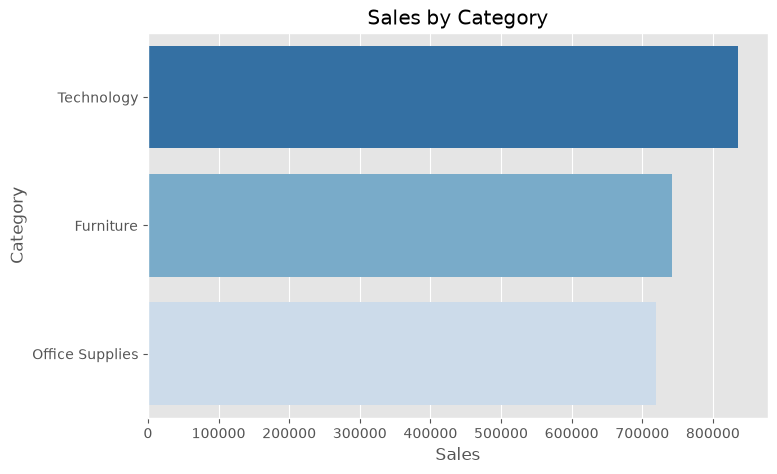

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=sales_category.values,
    y=sales_category.index,
    hue=sales_category.index,
    palette="Blues_r",
    legend=False
)

plt.title("Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")

plt.show()

In [41]:
profit_category = (
    df_clean.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

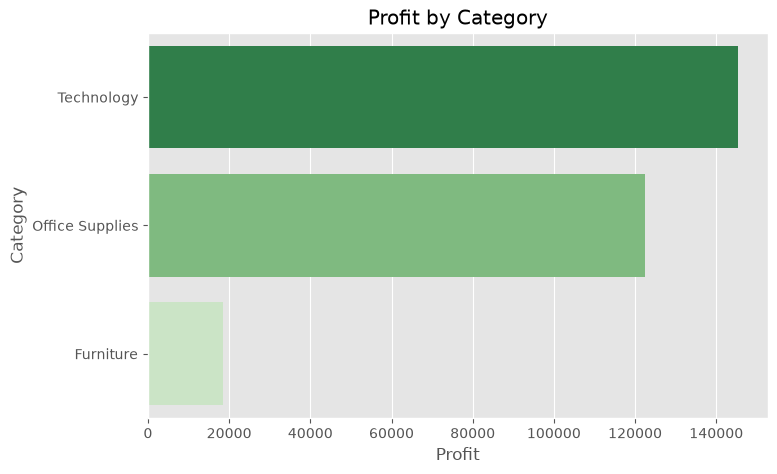

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_category.values,
    y=profit_category.index,
    hue=profit_category.index,
    palette="Greens_r",
    legend=False
)

plt.title("Profit by Category")

plt.xlabel("Profit")

plt.ylabel("Category")

plt.show()

In [44]:
sales_region = (
    df_clean.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

sales_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

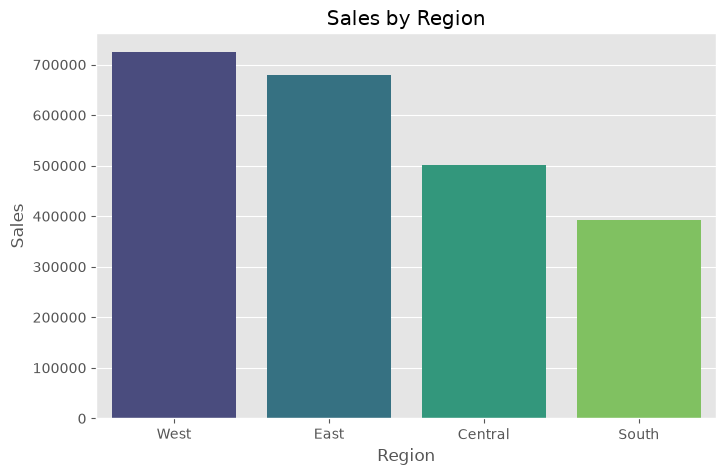

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=sales_region.index,
    y=sales_region.values,
    hue=sales_region.index,
    palette="viridis",
    legend=False
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

In [46]:
profit_region = (
    df_clean.groupby('Region')['Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_region

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

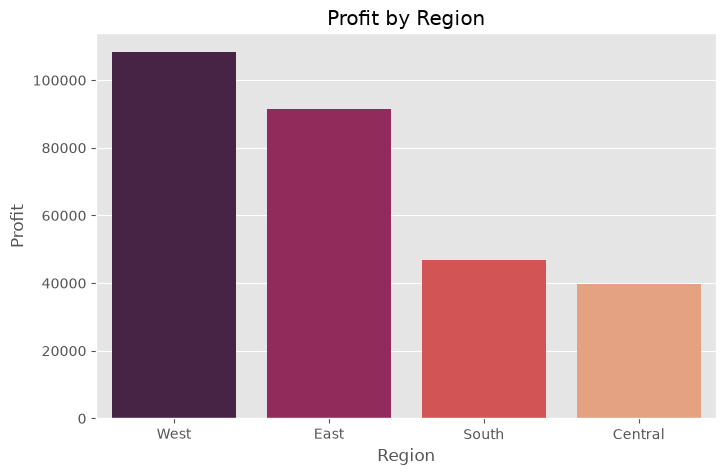

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_region.index,
    y=profit_region.values,
    hue=profit_region.index,
    palette="rocket",
    legend=False
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

In [48]:
monthly_sales = (
    df_clean.groupby('Order Month')['Sales']
    .sum()
)

In [49]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

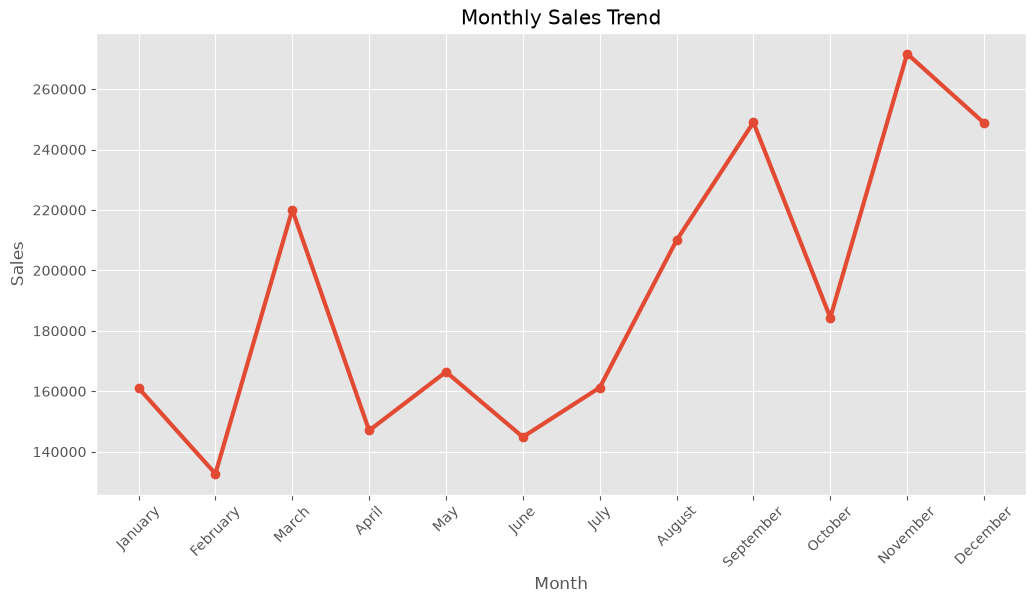

In [50]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=3
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [51]:
top_products = (
    df_clean.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

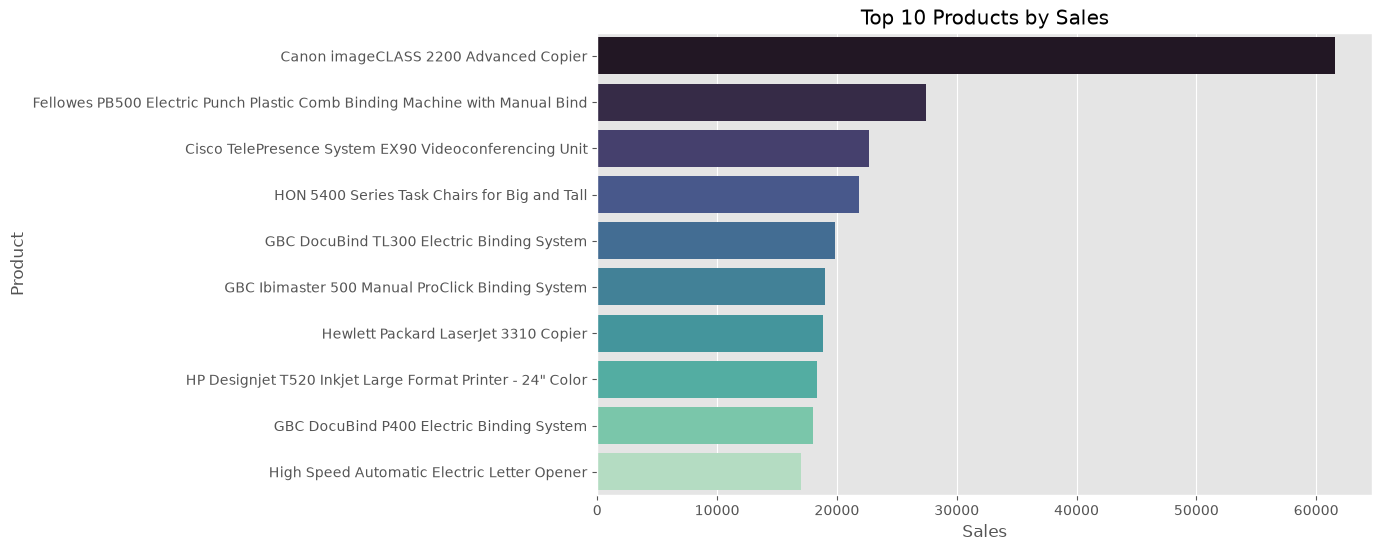

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="mako",
    legend=False
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

In [53]:
top_customers = (
    df_clean.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

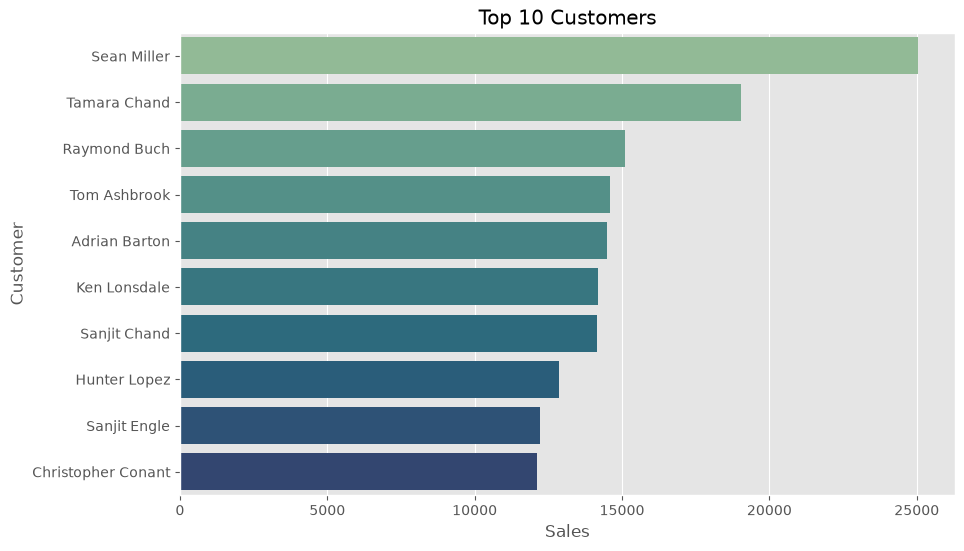

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    hue=top_customers.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Customers")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.show()

In [55]:
segment_analysis = df_clean.groupby('Segment').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Orders=('Order ID','nunique'),
    Customers=('Customer ID','nunique')
)

segment_analysis

,Total_Sales,Total_Profit,Orders,Customers
Segment,,,,
Consumer,1.161401e+06,134119.2092,2586,409
Corporate,7.061464e+05,91979.1340,1514,236
Home Office,4.296531e+05,60298.6785,909,148


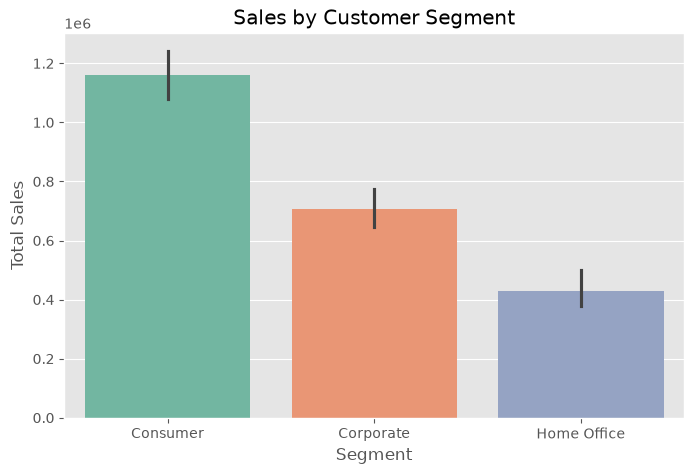

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x='Segment',
    y='Sales',
    hue='Segment',
    estimator=sum,
    palette='Set2',
    legend=False
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.show()

In [57]:
ship_analysis = df_clean.groupby('Ship Mode').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Avg_Shipping_Days=('Ship Days','mean')
)

ship_analysis

,Total_Sales,Total_Profit,Avg_Shipping_Days
Ship Mode,,,
First Class,3.514284e+05,48969.8399,6.718466
Same Day,1.283631e+05,15891.7589,0.559853
Second Class,4.591936e+05,57446.6354,5.188175
Standard Class,1.358216e+06,164088.7875,12.180295


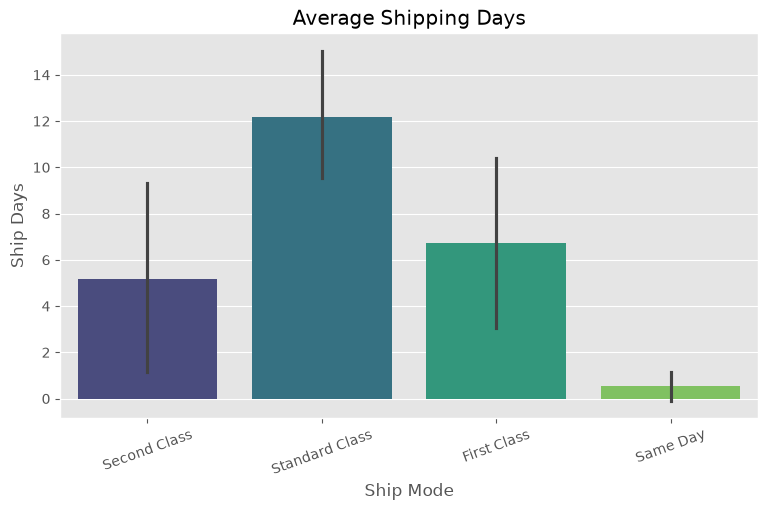

In [60]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_clean,
    x='Ship Mode',
    y='Ship Days',
    hue='Ship Mode',
    palette='viridis',
    legend=False
)

plt.title("Average Shipping Days")
plt.xticks(rotation=20)
plt.xlabel("Ship Mode")
plt.ylabel("Ship Days")

plt.show()

In [61]:
state_profit = (
    df_clean.groupby('State')['Profit']
    .sum()
    .sort_values(ascending=False)
)

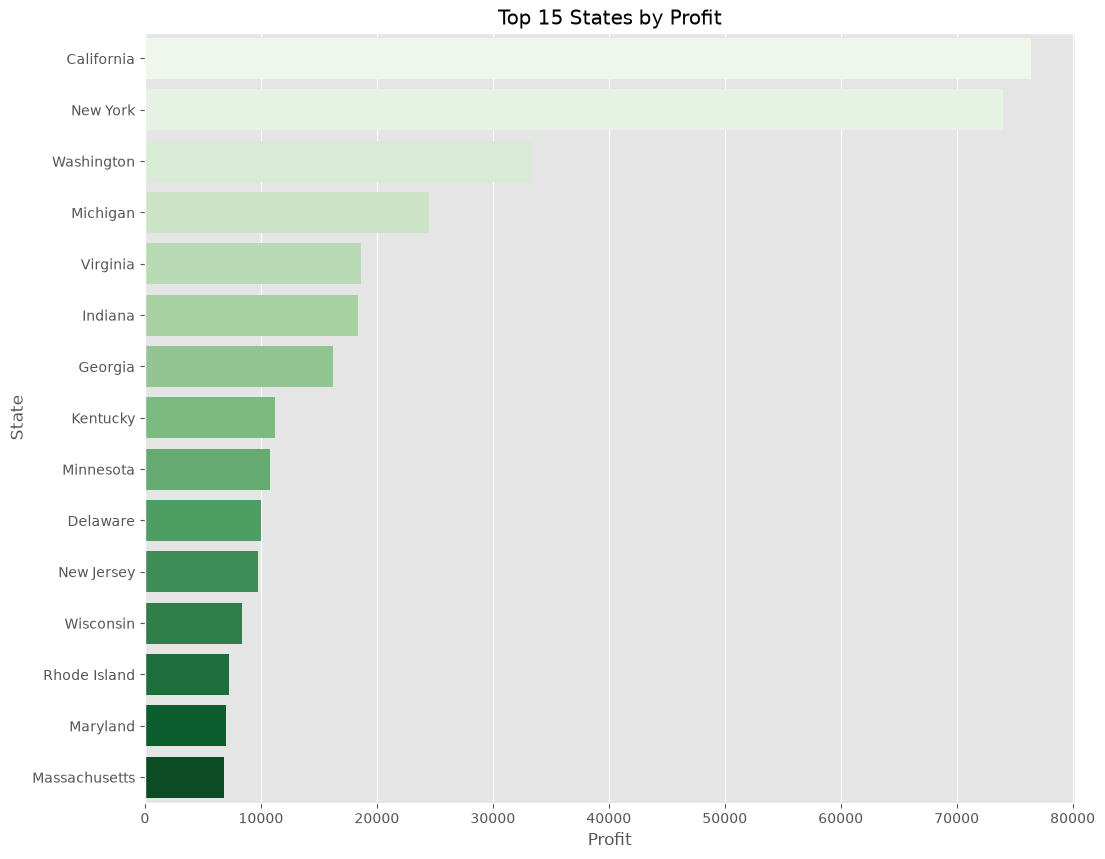

In [62]:
plt.figure(figsize=(12,10))

sns.barplot(
    x=state_profit.values[:15],
    y=state_profit.index[:15],
    hue=state_profit.index[:15],
    palette='Greens',
    legend=False
)

plt.title("Top 15 States by Profit")
plt.xlabel("Profit")
plt.ylabel("State")

plt.show()

In [63]:
bottom_states = state_profit.tail(15)

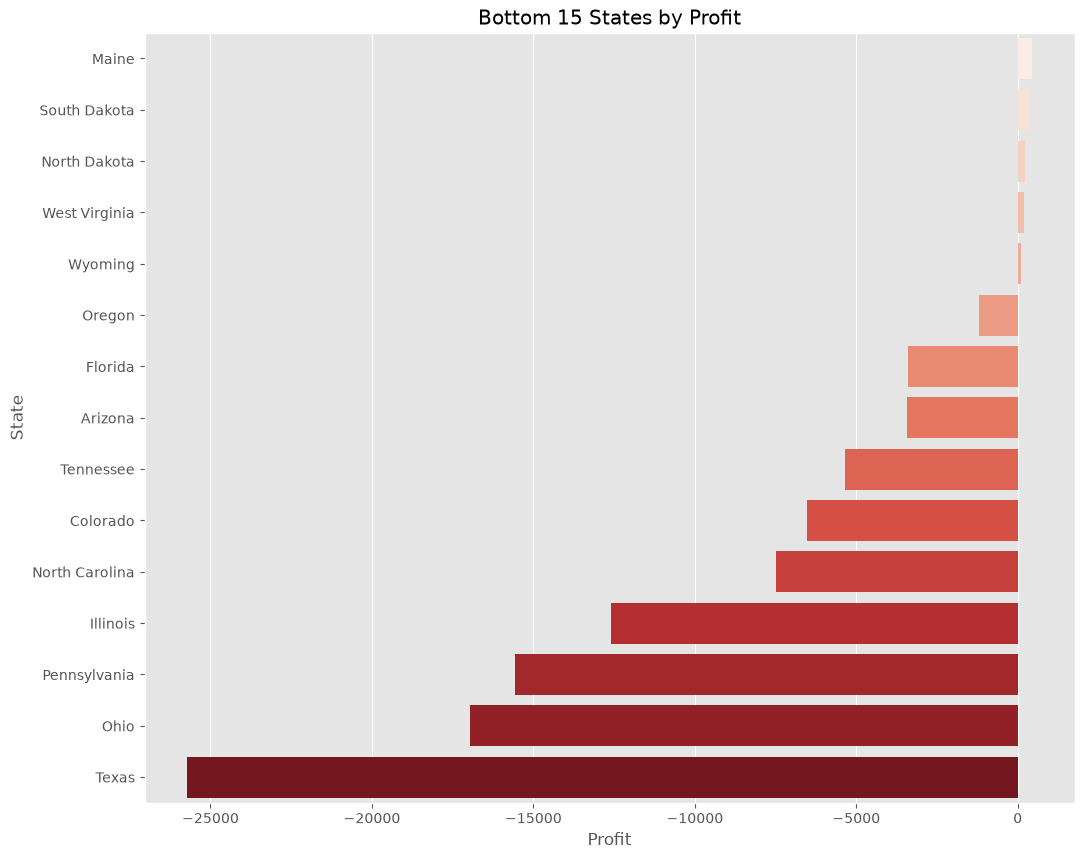

In [64]:
plt.figure(figsize=(12,10))

sns.barplot(
    x=bottom_states.values,
    y=bottom_states.index,
    hue=bottom_states.index,
    palette='Reds',
    legend=False
)

plt.title("Bottom 15 States by Profit")
plt.xlabel("Profit")
plt.ylabel("State")

plt.show()

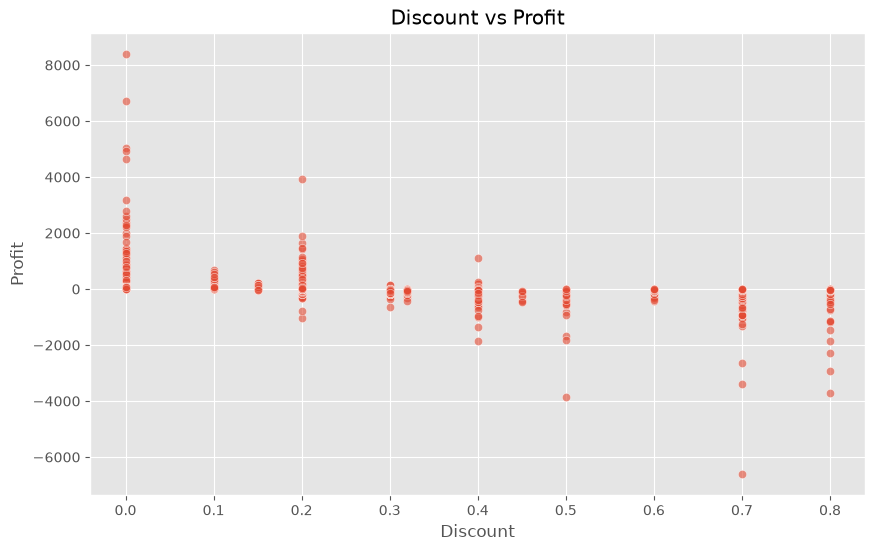

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='Discount',
    y='Profit',
    alpha=0.6
)

plt.title("Discount vs Profit")

plt.show()

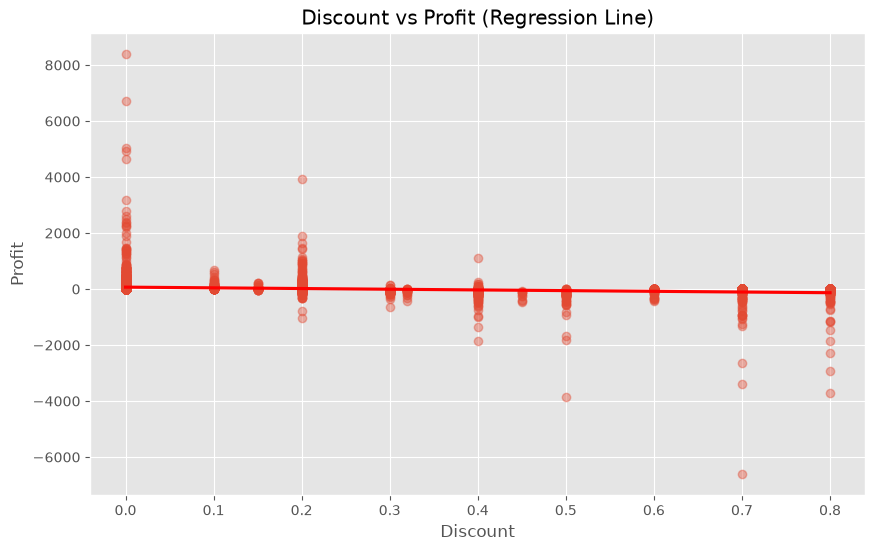

In [66]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_clean,
    x='Discount',
    y='Profit',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title("Discount vs Profit (Regression Line)")

plt.show()

In [67]:
numeric_cols = df_clean.select_dtypes(include=['number'])

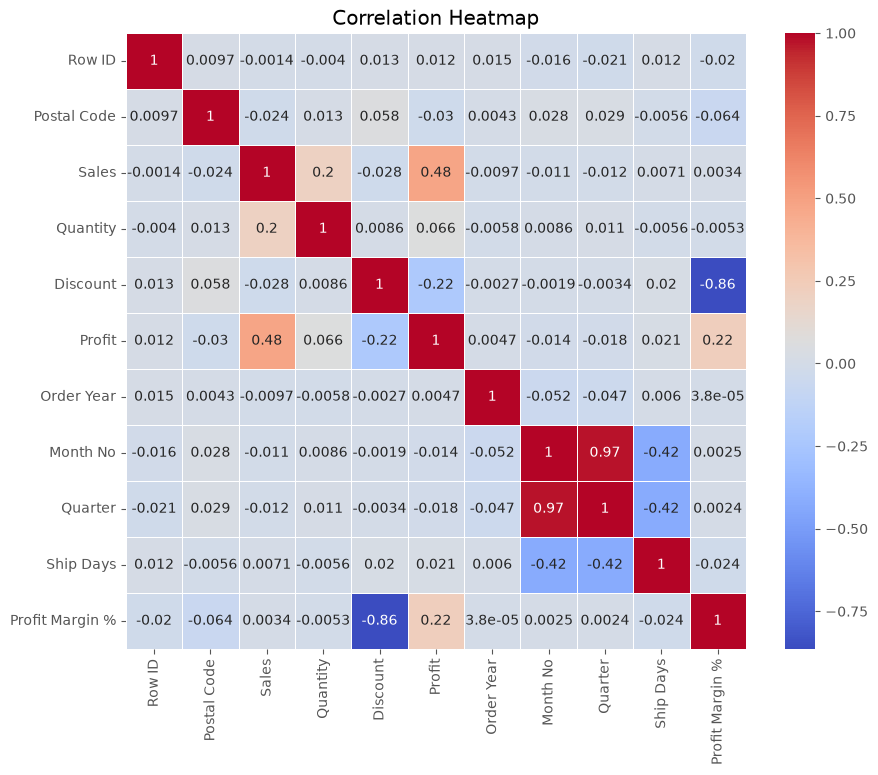

In [68]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [69]:
loss_products = (
    df_clean.groupby('Product Name')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

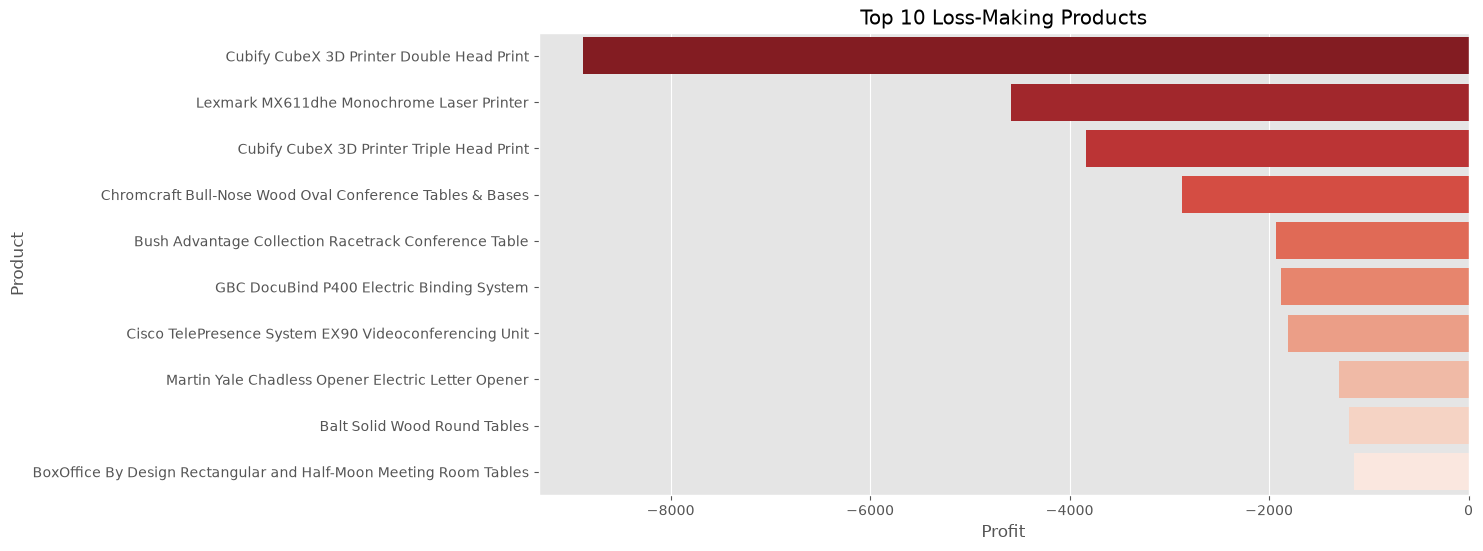

In [70]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=loss_products.values,
    y=loss_products.index,
    hue=loss_products.index,
    palette='Reds_r',
    legend=False
)

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.show()

In [71]:
margin = (
    df_clean.groupby('Category')['Profit Margin %']
    .mean()
)

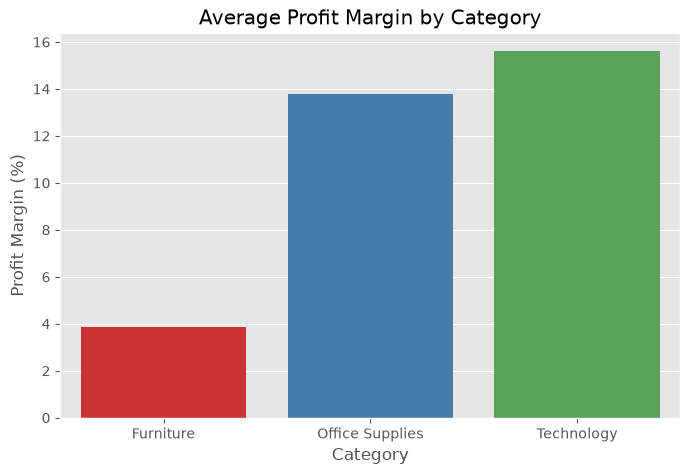

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=margin.index,
    y=margin.values,
    hue=margin.index,
    palette='Set1',
    legend=False
)

plt.title("Average Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.show()

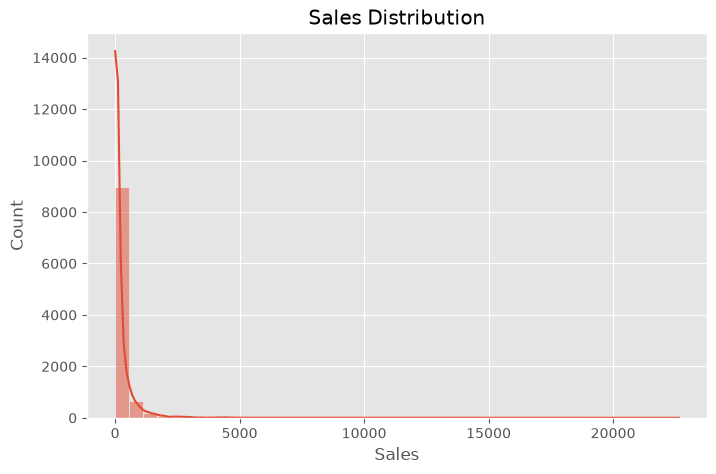

In [73]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean['Sales'],
    bins=40,
    kde=True
)

plt.title("Sales Distribution")

plt.show()

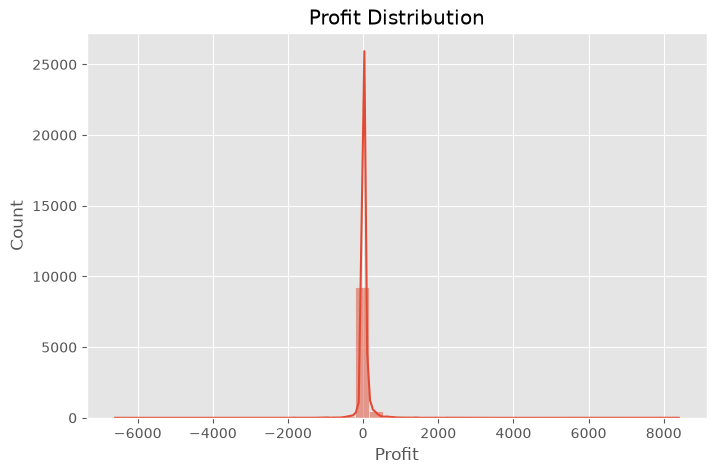

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean['Profit'],
    bins=40,
    kde=True
)

plt.title("Profit Distribution")

plt.show()

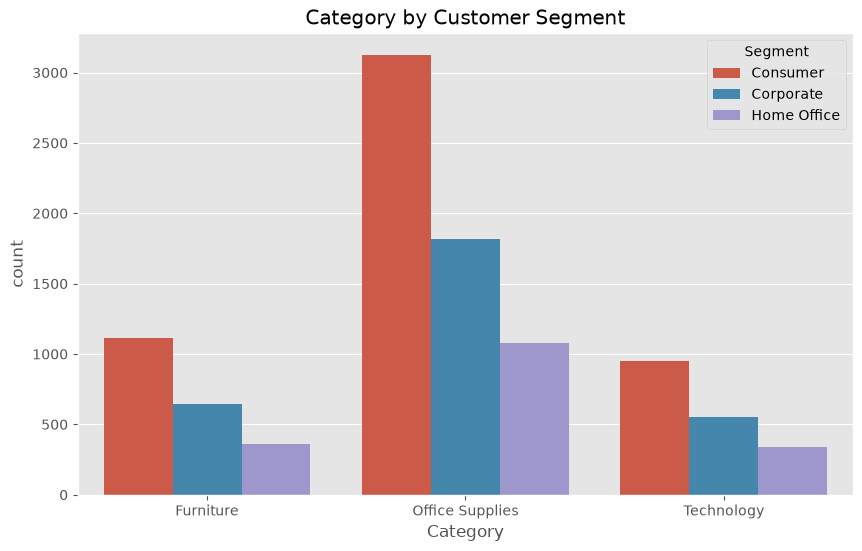

In [75]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_clean,
    x='Category',
    hue='Segment'
)

plt.title("Category by Customer Segment")

plt.show()

In [76]:
year_analysis = df_clean.groupby('Order Year').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum')
)

year_analysis

,Total_Sales,Total_Profit
Order Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


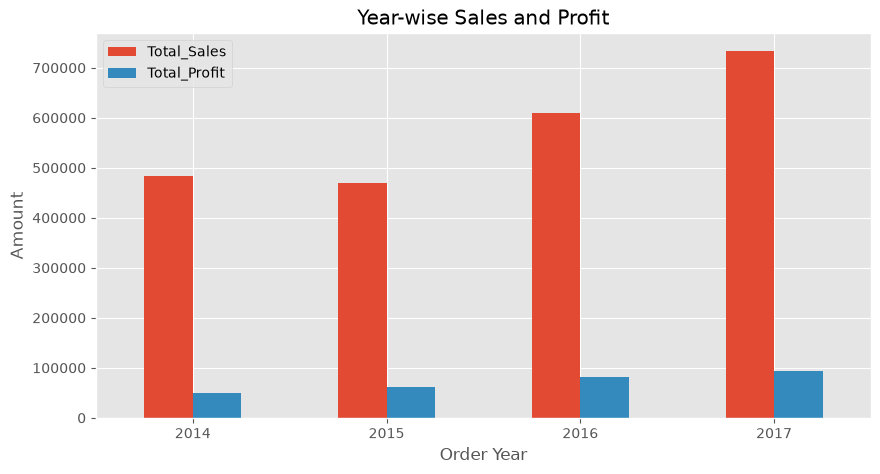

In [77]:
year_analysis.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Year-wise Sales and Profit")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.show()

In [78]:
year_analysis['Sales Growth %'] = (
    year_analysis['Total_Sales'].pct_change()*100
).round(2)

year_analysis

,Total_Sales,Total_Profit,Sales Growth %
Order Year,,,
2014,484247.4981,49543.9741,NaN
2015,470532.5090,61618.6037,-2.83
2016,609205.5980,81795.1743,29.47
2017,733215.2552,93439.2696,20.36


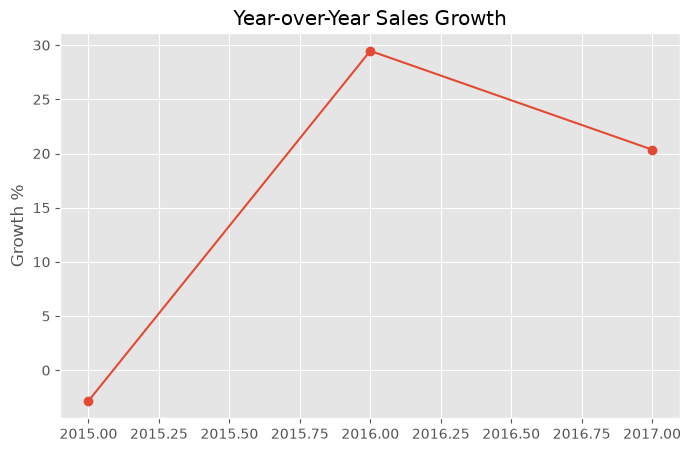

In [79]:
plt.figure(figsize=(8,5))

plt.plot(
    year_analysis.index,
    year_analysis['Sales Growth %'],
    marker='o'
)

plt.title("Year-over-Year Sales Growth")
plt.ylabel("Growth %")

plt.grid(True)

plt.show()

In [80]:
df_clean['YearMonth'] = df_clean['Order Date'].dt.to_period('M')

In [81]:
monthly = df_clean.groupby('YearMonth')['Sales'].sum()

monthly.head()

YearMonth
2014-01    28953.706
2014-02    12743.108
2014-03    54801.906
2014-04    24710.016
2014-05    29639.834
Freq: M, Name: Sales, dtype: float64

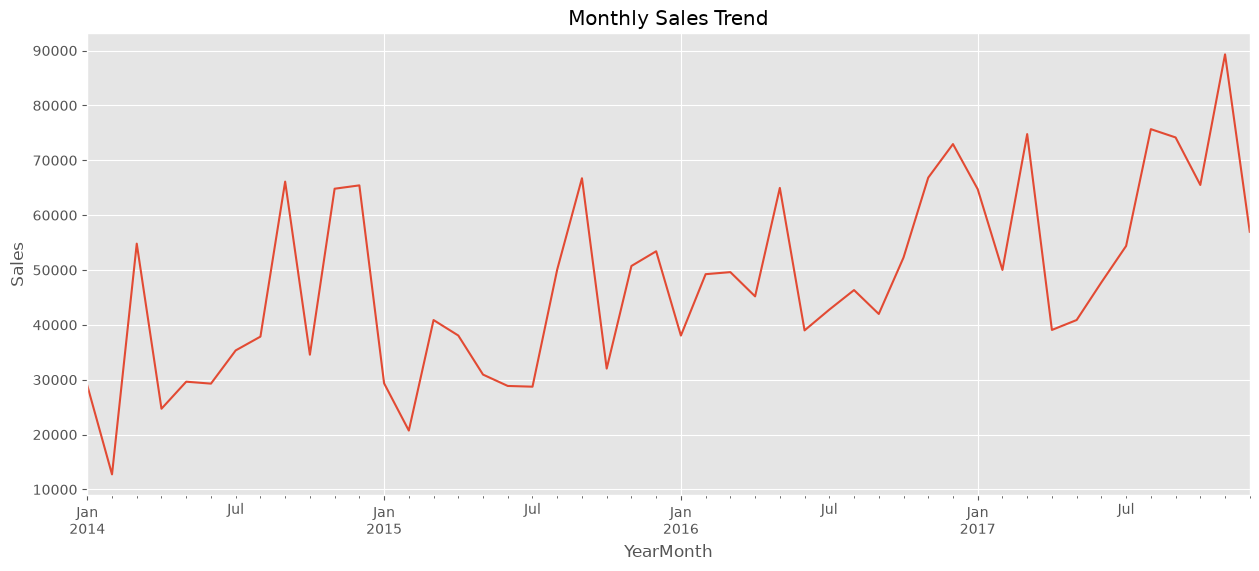

In [82]:
plt.figure(figsize=(15,6))

monthly.plot()

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

In [83]:
top_city = (
    df_clean.groupby('City')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

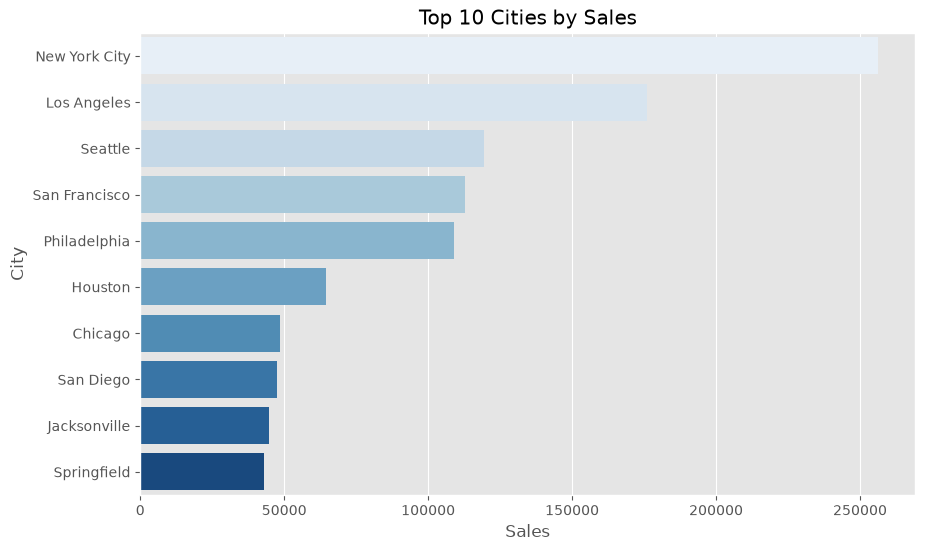

In [84]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_city.values,
    y=top_city.index,
    hue=top_city.index,
    palette='Blues',
    legend=False
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales")
plt.ylabel("City")

plt.show()

In [85]:
customer = (
    df_clean.groupby('Customer Name')
    .agg(
        Orders=('Order ID','nunique'),
        Revenue=('Sales','sum'),
        Profit=('Profit','sum')
    )
)

customer.sort_values(
    by='Revenue',
    ascending=False
).head(10)

,Orders,Revenue,Profit
Customer Name,,,
Sean Miller,5,25043.050,-1980.7393
Tamara Chand,5,19052.218,8981.3239
Raymond Buch,6,15117.339,6976.0959
Tom Ashbrook,4,14595.620,4703.7883
Adrian Barton,10,14473.571,5444.8055
Ken Lonsdale,12,14175.229,806.8550
Sanjit Chand,9,14142.334,5757.4119
Hunter Lopez,6,12873.298,5622.4292
Sanjit Engle,11,12209.438,2650.6769


In [86]:
top_profit_products = (
    df_clean.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

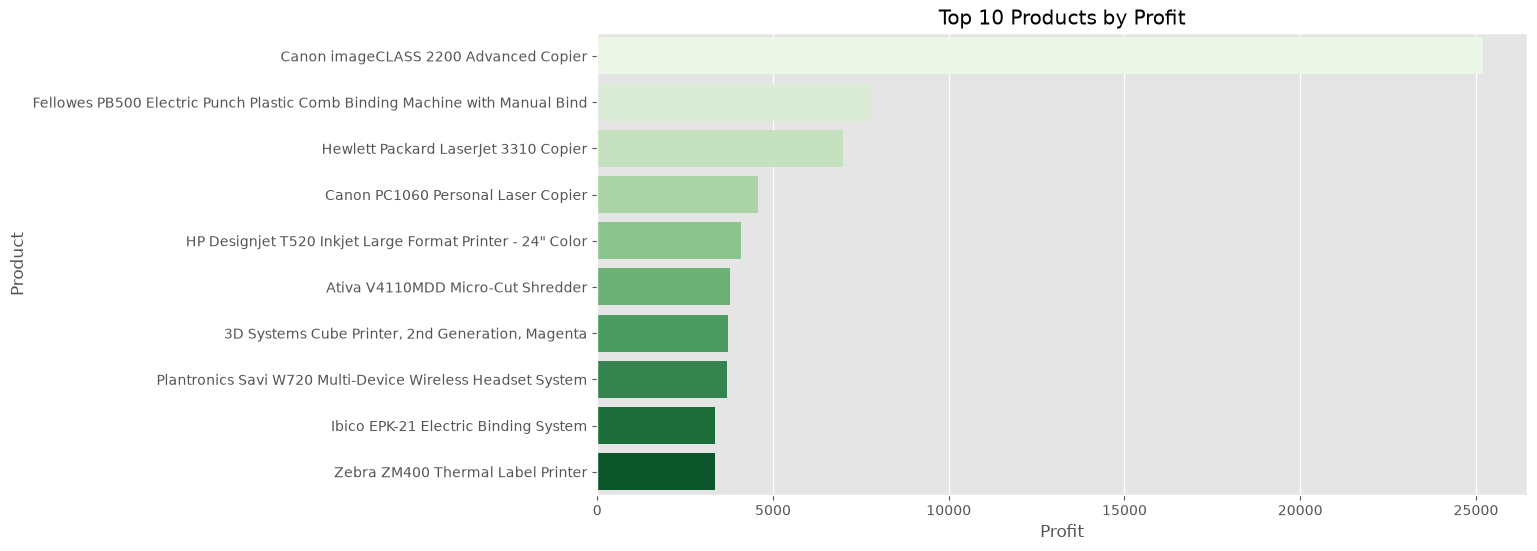

In [87]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_profit_products.values,
    y=top_profit_products.index,
    hue=top_profit_products.index,
    palette='Greens',
    legend=False
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.show()

In [88]:
bins = [0,0.1,0.2,0.3,0.5,1]

labels = [
    '0-10%',
    '10-20%',
    '20-30%',
    '30-50%',
    '50%+'
]

df_clean['Discount Band'] = pd.cut(
    df_clean['Discount'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [89]:
discount_summary = (
    df_clean.groupby('Discount Band')
    .agg(
        Sales=('Sales','sum'),
        Profit=('Profit','sum')
    )
)

discount_summary

,Sales,Profit
Discount Band,,
0-10%,1.142278e+06,330016.7802
10-20%,7.921529e+05,91756.2975
20-30%,1.032267e+05,-10369.2774
30-50%,1.953148e+05,-48447.7273
50%+,6.422874e+04,-76559.0513


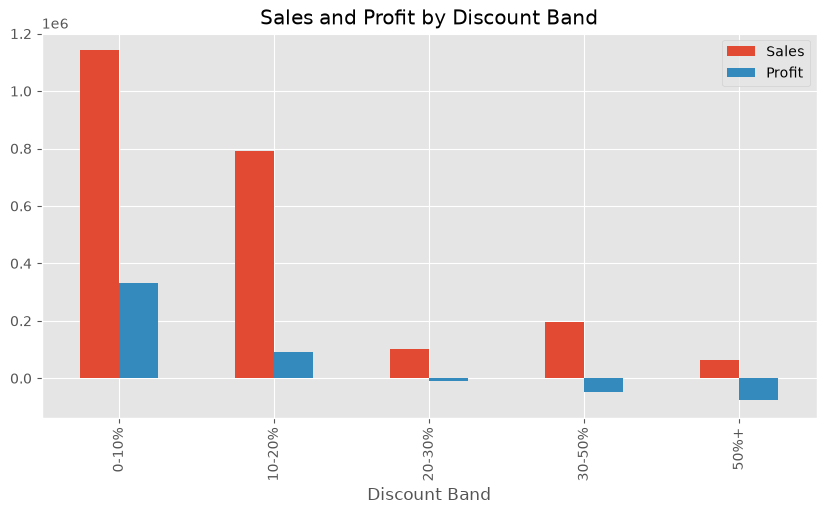

In [90]:
discount_summary.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Sales and Profit by Discount Band")

plt.show()

In [91]:
year_analysis.to_csv(
    "Year_Analysis.csv"
)

segment_analysis.to_csv(
    "Segment_Analysis.csv"
)

discount_summary.to_csv(
    "Discount_Analysis.csv"
)

customer.to_csv(
    "Customer_Analysis.csv"
)

In [92]:
print("="*50)

print("SUPERSTORE BUSINESS SUMMARY")

print("="*50)

print(f"Total Sales : ${df_clean['Sales'].sum():,.2f}")

print(f"Total Profit : ${df_clean['Profit'].sum():,.2f}")

print(f"Customers : {df_clean['Customer ID'].nunique()}")

print(f"Orders : {df_clean['Order ID'].nunique()}")

print(f"Products : {df_clean['Product ID'].nunique()}")

print(f"Average Shipping Days : {df_clean['Ship Days'].mean():.2f}")

print("="*50)

SUPERSTORE BUSINESS SUMMARY
Total Sales : $2,297,200.86
Total Profit : $286,397.02
Customers : 793
Orders : 5009
Products : 1862
Average Shipping Days : 9.35
